In [1]:
import os
import sys
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import torch

import numpy as np
from torch.nn.functional import softmax
import matplotlib.pyplot as plt

from PIL import Image
from torch.autograd import Variable
from classes.classifier import VocalNoiseClassifier, VocalDatasetFromFolder

In [28]:
NoiseClassifier = VocalNoiseClassifier('/Users/gustavo/Documents/git/vocalpy/audios/1773_Agrp-Trpv1_1st_Stage_outputs/spectrogram')

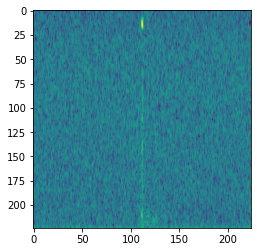

In [38]:
img = NoiseClassifier.dataset.__getitem__(7)
plt.imshow(img.cpu().numpy()[0,:,:])

In [36]:
NoiseClassifier.model.eval()

# summary for probability distribution
predictions = []

# compute metrics over the dataset
for itr, image in enumerate(NoiseClassifier.dataloader):
    image = image.to(NoiseClassifier.device)
    image = Variable(image)

    score = NoiseClassifier.model(image)
#     probabilities = softmax(score, dim=1).detach().numpy()
    _, predicted = torch.max(score.data, 1)
    summry.append(predicted.numpy())
predictions = np.hstack(predictions)

In [37]:
summry

[array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1]),
 array([1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0]),
 array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 

In [40]:
np.hstack(summry)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
torch.max(score.data, dim=1)

In [ ]:
NoiseClassifier = VocalNoiseClassifier('/Users/gustavo/Documents/git/vocalpy/audios/1773_Agrp-Trpv1_1st_Stage_outputs/spectrogram', batch_size=1)
dataiter = iter(NoiseClassifier.dataloader)

/Users/gustavo/anaconda3/envs/main/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  # This is added back by InteractiveShellApp.init_path()


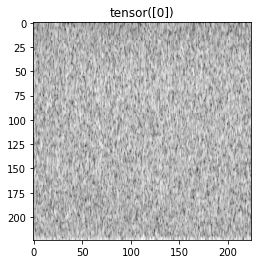

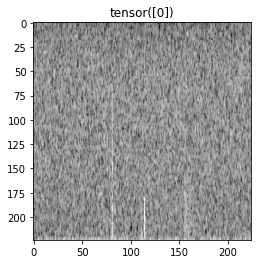

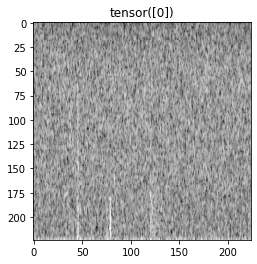

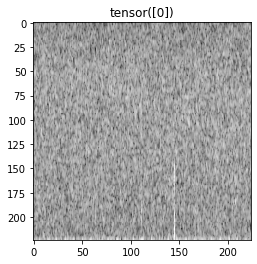

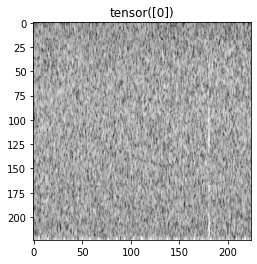

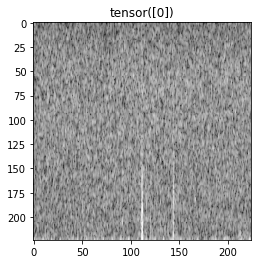

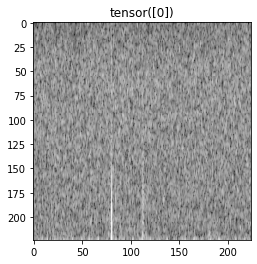

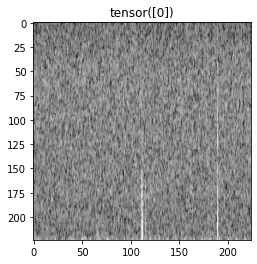

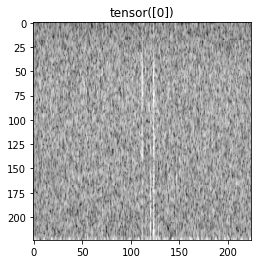

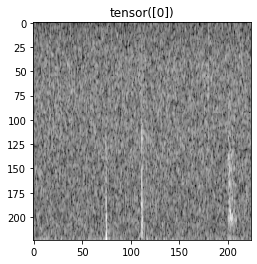

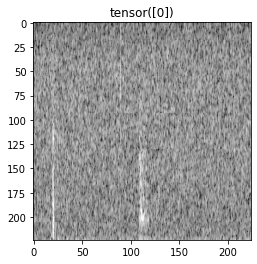

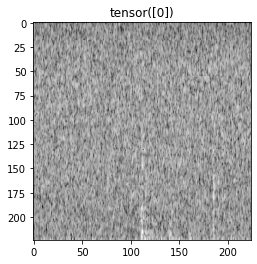

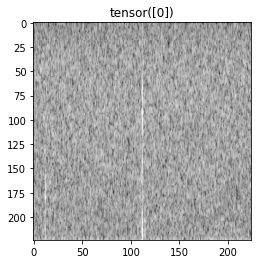

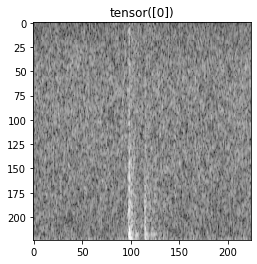

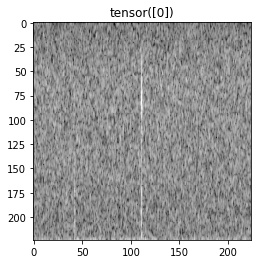

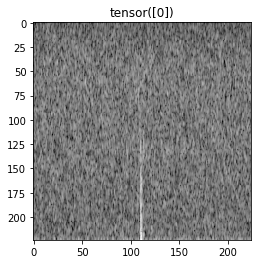

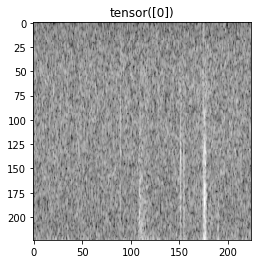

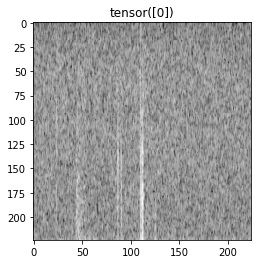

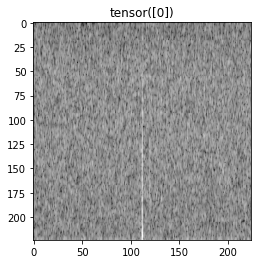

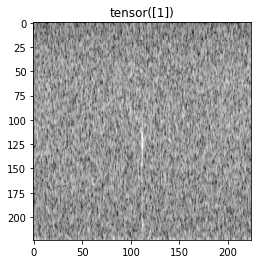

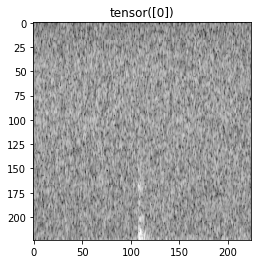

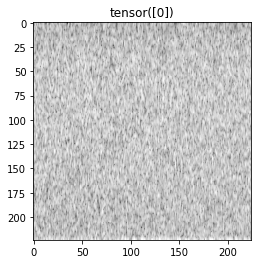

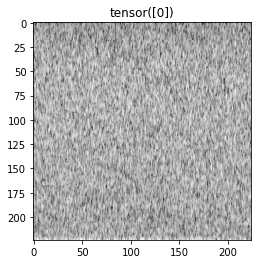

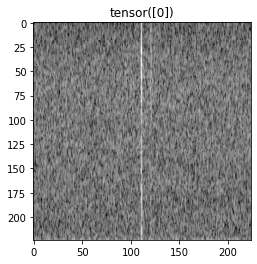

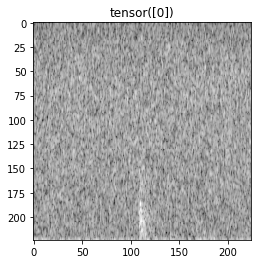

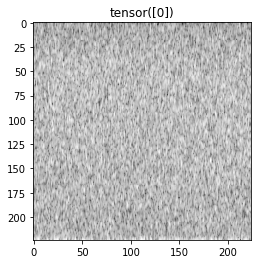

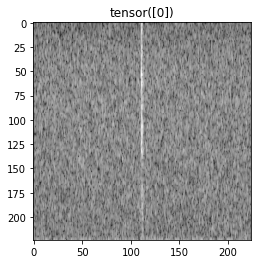

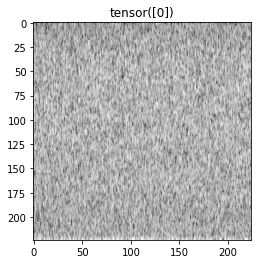

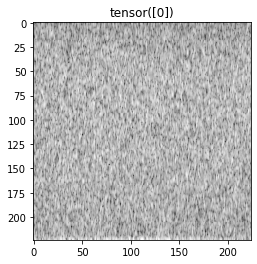

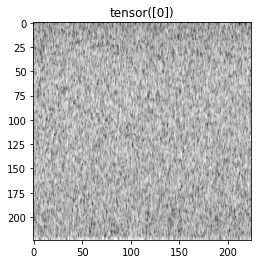

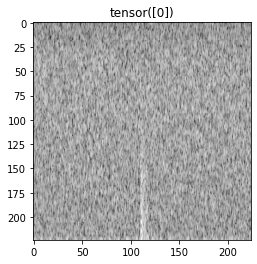

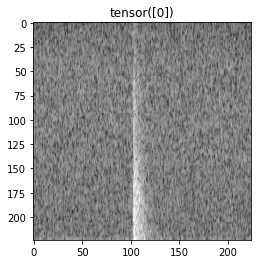

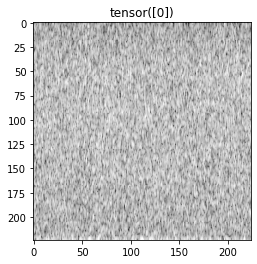

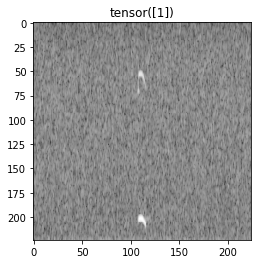

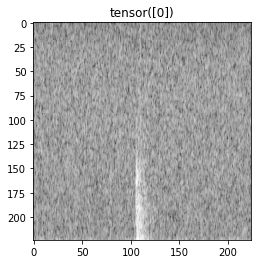

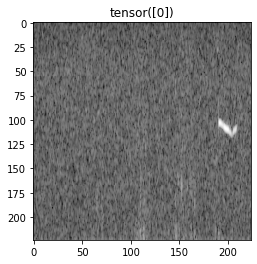

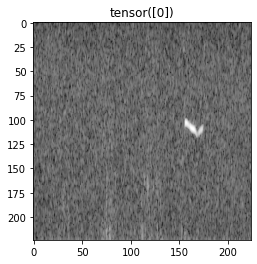

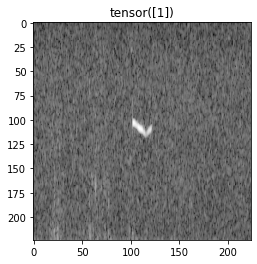

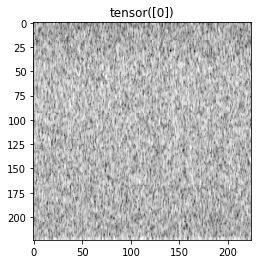

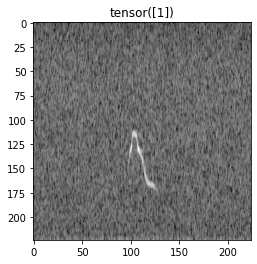

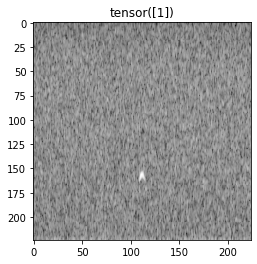

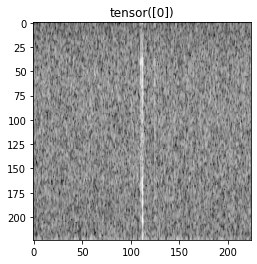

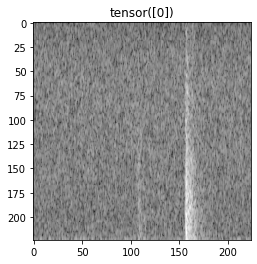

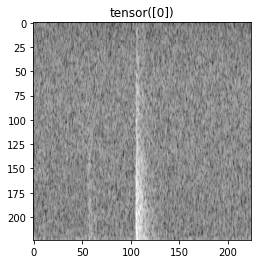

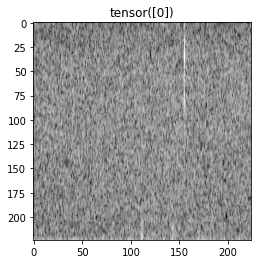

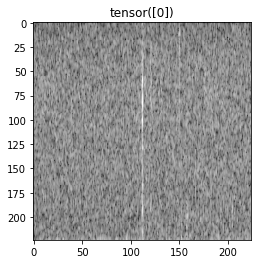

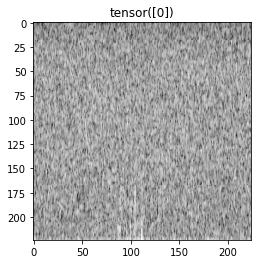

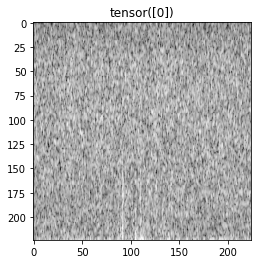

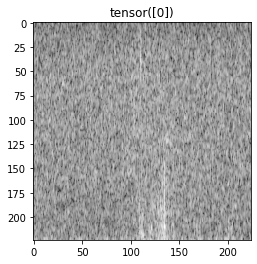

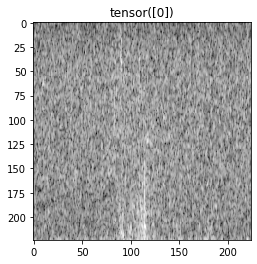

In [25]:
for i in range(0,50):
    NoiseClassifier.model.train(mode=False)
    img = dataiter.next()

    image = img.to(NoiseClassifier.device)
    image = Variable(image)

    score = NoiseClassifier.model(image)
    #     probabilities = softmax(score, dim=1).detach().numpy()
    _, predicted = torch.max(score.data, 1)
    plt.figure()
    plt.imshow(img.cpu().numpy()[0,0,:,:], cmap='gray')
    plt.title(str(predicted))

In [49]:
a = np.array([0,1,2,3,4,5,6,7,8,9])
b = np.array([0,1,0,1,0,1,0,1,0,1]).astype('bool')

In [51]:
a[b]

array([1, 3, 5, 7, 9])

In [53]:
np.hstack(summry).astype('bool')

array([False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True, False, False, False, False,  True, False,  True,
        True,  True,  True, False, False,  True, False, False,  True,
        True, False, False,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True, False, False, False, False, False,  True,  True,
       False, False,  True,  True,  True, False,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False,